<a href="https://colab.research.google.com/github/mcjkurz/qhchina/blob/main/tutorials/Intro_to_Python_for_Chinese_Humanities_Part_2_Working_with_Texts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Python for Chinese Humanities: Part 2, Working with Texts

**Welcome to Part 2 of the Tutorial!**

In this tutorial, we will work with Chinese texts.

We will learn how to segment them into individual words (分詞) and find some basic statistics about the word distribution.

First, let's create a directory (文件夹) called "data," in which we will store our files. We can use the `mkdir` command to do that. Plase run the following line.

In [1]:
!mkdir data

Then, click on the "refresh" button to see the new folder.
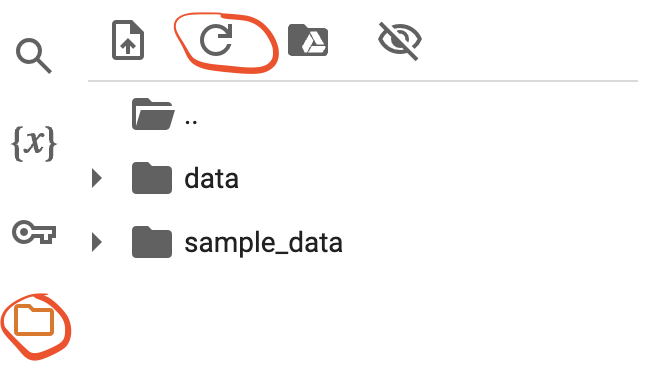

Now, let's download some sample texts into this new directory. We will download three parts (卷) of Gao Ertai's *In Search of My Homeland* 《尋找家園》. To do that, we will use the command `wget`.

**You can also upload your own texts (.txt files).** Simply click on the three dots sign to the right of `data` folder and then click `Upload` (`上传`). Make sure your files are in UTF-8 encoding.

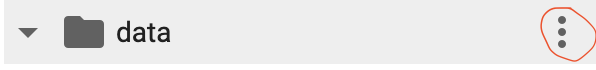

If you don't upload your own files, run the following code to download Gao Ertai's book.

In [2]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/GaoErTai_XunzhaoJiayuan_1.txt -P data/
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/GaoErTai_XunzhaoJiayuan_2.txt -P data/
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/GaoErTai_XunzhaoJiayuan_3.txt -P data/

--2024-09-25 03:06:01--  https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/GaoErTai_XunzhaoJiayuan_1.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 127799 (125K) [text/plain]
Saving to: ‘data/GaoErTai_XunzhaoJiayuan_1.txt’

GaoErTai_XunzhaoJia 100%[===================>] 124.80K  --.-KB/s    in 0.03s   

2024-09-25 03:06:02 (4.75 MB/s) - ‘data/GaoErTai_XunzhaoJiayuan_1.txt’ saved [127799/127799]

--2024-09-25 03:06:02--  https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/GaoErTai_XunzhaoJiayuan_2.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199

Now, we will need to create a list of filenames. This list is required because we will be reading from the downloaded files, one by one, in a loop.

The list of filenames can be found with the help of `os` library.

Specifically, the function `os.listdir(directory)` returns a list of filenames in the specified `directory.`

**We will only consider the .txt files.** To remove everything else (files that are not .txt), we will use the in-built function `.endswith()`.

In [3]:
import os
filenames = [filename for filename in os.listdir("data") if filename.endswith(".txt")]
print(filenames)

['GaoErTai_XunzhaoJiayuan_1.txt', 'GaoErTai_XunzhaoJiayuan_2.txt', 'GaoErTai_XunzhaoJiayuan_3.txt']


Now, we will read these files, one by one, in a loop. **We will need to append the prefix `data/` to each filename within the loop, so that the computer can find them.**

We use the `open` function to read files.

`open` takes many arguments. We will provide three to make our `file_reader`:

1. the full filename **(including the `data/` prefix)**,
2. the mode of access to this file (`"r"` for "read")
3. encoding (`UTF-8`).

We will then use this file_reader to `read()` the entire .txt file.

We need to remember to `close` the file reader after we finish reading from the file.

After reading each .txt file, we will append its content (the text) to our list `texts`.

In [4]:
import os

texts = [] # empty list, we will append to it in a loop

for filename in filenames:
  full_filename = "data/" + filename # we add the prefix!
  print("Reading " + full_filename + "...")

  file_reader = open(full_filename, "r", encoding="UTF-8")
  text = file_reader.read()
  file_reader.close()

  print("Finished!")
  texts.append(text)

print("I have loaded " + str(len(texts)) + " files.")

Reading data/GaoErTai_XunzhaoJiayuan_1.txt...
Finished!
Reading data/GaoErTai_XunzhaoJiayuan_2.txt...
Finished!
Reading data/GaoErTai_XunzhaoJiayuan_3.txt...
Finished!
I have loaded 3 files.


In [5]:
print("How many characters (including spaces) in the first file:", len(texts[0]))

How many characters (including spaces) in the first file: 43453


In [6]:
print(texts[0][:200]) # print the first 200 characters of the first file.

【卷一　梦里家山】





梦里家山





　　我的故乡高淳，位于江苏省西南端与安徽省交界的地方，恰好是「吴头楚尾」。地势东高西低。东部是茅山山脉和天目山山脉的衔接处，山高林茂，俗称「山乡」；西部为丹阳湖、石臼湖、小南湖三湖所环绕，溪河交错，苇岸无穷，俗称「圩乡」。最早的县治固城始建于公元前五四一年，比楚威王筑石头城置金陵邑（前三三三年）还早二百来年，可称古邑。



　　到我出生的时候，固


Notice that the texts need some editing and pre-processing. For example, the sentences are broken into lines, and there are many empty spaces.

Let's remove the line-breakers (换行) using a simple trick. We first use the in-built `.split()` function to split the text into individual lines. Then, we will use `"".join()` function to bring them back again into a very long string.

Before doing this on our texts, let's try this simple example:

In [7]:
text_with_many_lines = """這是第一行。
這是第二行。
這是第三行。"""
print(text_with_many_lines) # one string, with lines separated by line-breakers

這是第一行。
這是第二行。
這是第三行。


Now, we use the `.split()` function to split this three-lines text into a list. Each element is one line.

In [8]:
list_of_lines = text_with_many_lines.split()
print(list_of_lines) # list with three elements

['這是第一行。', '這是第二行。', '這是第三行。']


Now, we combine the lines into one single string (字串) using the `"".join()` function.

In [9]:
lines_combined = "".join(list_of_lines)
print(lines_combined) # one string

這是第一行。這是第二行。這是第三行。


We will use this trick to do the same with our texts.

We use a loop, and for each text (`texts[index]`), we first split it with `.split()` function and then join it with the `"".join()` function.

In [10]:
for index in range(len(texts)):
  texts[index] = "".join(texts[index].split())

In [11]:
print(texts[0][:200]) # again, let's print the first 200 characters of the first file.

【卷一梦里家山】梦里家山我的故乡高淳，位于江苏省西南端与安徽省交界的地方，恰好是「吴头楚尾」。地势东高西低。东部是茅山山脉和天目山山脉的衔接处，山高林茂，俗称「山乡」；西部为丹阳湖、石臼湖、小南湖三湖所环绕，溪河交错，苇岸无穷，俗称「圩乡」。最早的县治固城始建于公元前五四一年，比楚威王筑石头城置金陵邑（前三三三年）还早二百来年，可称古邑。到我出生的时候，固城早已荒废，县治淳溪镇也只是一个仅数千户人


Hurray! The line breakers are gone!

## Word segmentation for Chinese

Unlike English, in Chinese there are no spaces between words. This poses a problem for text analysis.

For very short texts, we can segment them into separate tokens (words) ourselves.

In [12]:
text = "我今天很开心。"
word_list = ["我", "今天", "很", "开心","。"]
print(len(word_list))

5


In [13]:
for word in word_list:
  print(word)

我
今天
很
开心
。


For larger texts, however, we need some help.

Fortunately, there **are free, open-source models that we can use to segment Chinese texts.**

In this example, we will use `spacy` model for Chinese, `zh_core_web_lg`.

Let's first download and load the model. This might take around 30 seconds.

In [14]:
!python -m spacy download zh_core_web_lg
import spacy
nlp = spacy.load("zh_core_web_lg")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.0/603.0 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 20.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Let's now segment our short example sentence ("我今天很開心") using the model we have just downloaded.

To do that, we can use the function `nlp` and provide the text as the argument.

The function `nlp` will return a list of tokens (words). Each token in this list has some important properties. For example:

*   `token.text` -- this is the actual word
*   `token.pos_` -- this is the part-of-speech tag of this word (noun, verb, etc).
*   `token.lemma_` -- this is the lemmatized version of the word ("doughnuts" -> "doughnut", "are" -> "be", etc.)

Let's try!


In [15]:
sentence = "我今天很开心。"

segmented_sentence = nlp(sentence) # this will return a list of tokens

print([token.text for token in segmented_sentence]) # let's print a list of words

['我', '今天', '很', '开心', '。']


**Part-of-Speech (POS)** is a very useful category. For example, we might want to remove all punctuation marks (。，“； etc.) from our list of words.

Each token has its tag (called POS-tag). We can access it through `.pos_`. The full list of tags can be seen here: https://universaldependencies.org/u/pos/

In [16]:
print([token.pos_ for token in segmented_sentence])

['PRON', 'NOUN', 'ADV', 'VERB', 'PUNCT']


Let's combine two properties and print them in a loop.

In [17]:
for token in segmented_sentence:
  print("Token: " + token.text + ", Part of Speech: " + token.pos_)

Token: 我, Part of Speech: PRON
Token: 今天, Part of Speech: NOUN
Token: 很, Part of Speech: ADV
Token: 开心, Part of Speech: VERB
Token: 。, Part of Speech: PUNCT


The model is roughly correct.
* "我" is a pronoun (PRON),
* "今天" is a noun (NOUN),
* "很" is an adverb (ADV),
etc.

Let's now go back to our `texts`. As you remember, each element in `texts` is a very long string, without line-breakers.

We will separate these strings, one by one, into individual tokens, removing punctuation, spaces, and special symbols (if any).

This might take some time (even a few minutes), depending on the size of your files.

Notice that I also truncate (cut) the text if it is longer than the `max_length` set by `nlp`.

*This process can be made faster by providing additional argument to `nlp`: disable=['parser','ner'].*

In [18]:
segmented_texts = []

excluded_pos = ["PUNCT", "SYM", "SPACE"] # the part of speech tags we want to remove (can add yours; maybe you want to focus on verbs only?)

for text in texts:
  if len(text) > nlp.max_length:
    text = text[:nlp.max_length] # only the first nlp.max_length tokens (this is a huge number so no worries)
  segmented_text = nlp(text)
  text_tokens = [token.text for token in segmented_text if token.pos_ not in excluded_pos]
  segmented_texts.append(text_tokens)

Let's now print the first 100 tokens from our first segmented text.

In [19]:
print(segmented_texts[0][:100])

['【卷', '一', '梦', '里', '家山', '梦', '里', '家山', '我', '的', '故乡', '高淳', '位于', '江苏省', '西南端', '与', '安徽省', '交界', '的', '地方', '恰好', '是', '吴头楚尾', '地势', '东高西低', '东部', '是', '茅山山脉', '和', '天目山', '山脉', '的', '衔接处', '山高林茂', '俗称', '山乡', '西部', '为', '丹阳湖', '石臼湖', '小', '南湖', '三', '湖', '所', '环绕', '溪河', '交错', '苇岸无穷', '俗称', '圩乡', '最', '早', '的', '县治', '固城', '始建于', '公元前', '五四一年', '比', '楚威', '王筑', '石头', '城置', '金陵邑', '前', '三三三年', '还', '早', '二百', '来年', '可称', '古邑', '到', '我', '出生', '的', '时候', '固城', '早已', '荒废', '县治', '淳溪镇', '也', '只是', '一个', '仅', '数千', '户', '人家', '的', '小', '镇', '镇上', '只有', '一', '条', '三', '米', '多']


You can see that the model is often correct, but there are segmentation mistakes as well.

## Finding most common words



In this section, we will learn how to find the most common words in our dataset.

First, let's combine all segmented texts into one huge list. We will call it `all_tokens`.

The `all_tokens` list will contain all words (tokens) from all our texts combined together.

In [20]:
all_tokens = []
for segmented_text in segmented_texts:
  all_tokens += segmented_text

print("In total, there are " + str(len(all_tokens)) + " tokens.")

In total, there are 143744 tokens.


Now, let's find the most frequent tokens.

We will use the library `collections` and the class `Counter` from this library.

We can use `Counter` as a function, providing `all_tokens` as its argument.

In [21]:
from collections import Counter

token_counter = Counter(all_tokens)
token_counter.most_common(20) # print the 20 most common tokens

[('的', 7122),
 ('了', 3490),
 ('我', 3308),
 ('是', 2077),
 ('一', 1816),
 ('在', 1711),
 ('他', 1643),
 ('说', 1620),
 ('不', 1580),
 ('都', 1235),
 ('也', 1111),
 ('着', 1044),
 ('有', 1024),
 ('和', 999),
 ('就', 877),
 ('你', 797),
 ('个', 729),
 ('上', 722),
 ('我们', 709),
 ('到', 691)]

We see that some of the most frequent words are the so-called "function words": 的, 了, 是, 著, etc.

We can check how many times a token shows up by looking up its value in the dictionary `token_counter`.

In [22]:
print(token_counter["中国"])
print(token_counter["我"])
print(token_counter["abc"]) # "abc" should appear 0 times

82
3308
0


As noted previously, many of the most frequent words are the so-called "stopwords": words with little meaning that perform grammatical functions. We can remove them from the list to find more "informative," content words.

To do that, we need a list of Chinese stopwords. We can find it using the `nltk` library.

We can also add our own `custom_stopwords`.

In [23]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
stopwords = stopwords.words('chinese')
print(stopwords[:10]) # print the first 10 stopwords from the list

# we can also add custom stopwords:
custom_stopwords = ["一个", "这是", "东西"]
stopwords = stopwords + custom_stopwords

['一', '一下', '一些', '一切', '一则', '一天', '一定', '一方面', '一旦', '一时']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Now, we can use this list of stopwords to filter the most common words and keep only the non-stopwords.

We can also decide to keep only the words with at least two characters or longer.

The `token_counter.most_common(1000)` will return a list of 1000 elements.

Each element is a tuple `(token, frequency)`, for example the first element (most common) is `('的', 13173)`.

In the following line, we take the most common 1000 tokens, we filter out (remove) stopwords, and we keep only the tokens that are at least two characters long.

In [24]:
informative_tokens = [(token, frequency) for (token, frequency) in token_counter.most_common(1000) if token not in stopwords and len(token) > 1]
informative_tokens[:20]

[('敦煌', 141),
 ('回来', 118),
 ('父亲', 115),
 ('有人', 114),
 ('地方', 99),
 ('喜欢', 97),
 ('母亲', 96),
 ('政治', 96),
 ('小雨', 90),
 ('工作', 89),
 ('想到', 89),
 ('时间', 88),
 ('兰州', 86),
 ('农场', 83),
 ('中国', 82),
 ('生活', 81),
 ('发现', 81),
 ('革命', 81),
 ('眼睛', 80),
 ('老师', 80)]

## Making a wordcloud from the "informative" tokens

Let's visualize our findings. We need to first download the Chinese font, as Python does not support Chinese language visualization by default.

In [25]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/STSong.ttf

--2024-09-25 03:07:58--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/STSong.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11697600 (11M) [application/octet-stream]
Saving to: ‘STSong.ttf’

STSong.ttf          100%[===================>]  11.16M  72.0MB/s    in 0.2s    

2024-09-25 03:07:59 (72.0 MB/s) - ‘STSong.ttf’ saved [11697600/11697600]



You can read more about the WordCloud class here: https://amueller.github.io/word_cloud/generated/wordcloud.WordCloud.html

You can choose different color maps: https://matplotlib.org/stable/gallery/color/colormap_reference.html . I chose `plasma`, but you should try `viridis` or any other color set!

The following code will generate a wordcloud and save it as "wordcloud.png" in the local directory. You can download it to your computer.

If you don't like the final result, you can run the code as many times as you wish.

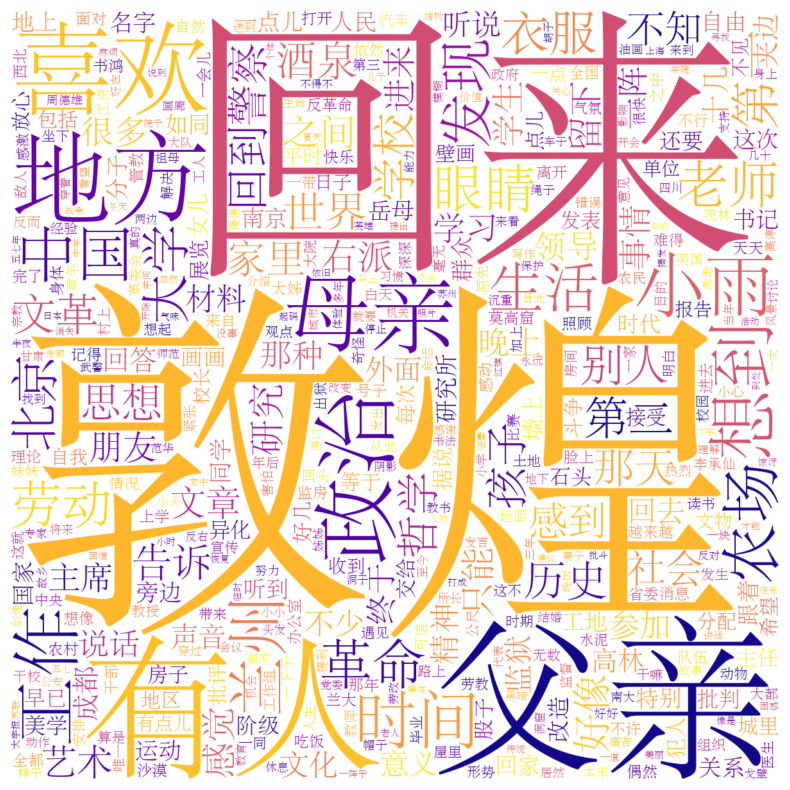

In [26]:
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image

# Convert back to a dictionary (WordCloud requires a dictionary)
frequencies_dict = dict(informative_tokens)

# Generate word cloud
wordcloud = WordCloud(font_path='STSong.ttf',
                      colormap="plasma",
                      max_words=500,
                      width=1200,
                      height=1200,
                      background_color='white')

wordcloud.generate_from_frequencies(frequencies_dict)

# Display the generated word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("wordcloud.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

That's the end of this tutorial. Congratulations!